In [1]:
#Natural Language Processing - NLP

#Assignment - WhatsApp Analysis Results (Application to analyse the WhatsApp chat)

#Algorithms used - Combinations of models like Counter Vector with Classification algorithms, IT-IDF Vector with Classification algorithms

In [2]:
#1.IMPORTING LIBRARIES

import re
# import → Python keyword that brings the specified module into the current program
# re → Built-in Python module for working with regular expressions (pattern matching in text)

import string
# import → Python keyword that brings the specified module into the current program
# string → Built-in Python module containing common string constants (e.g. punctuation, letters)

import pickle
# import → Python keyword that brings the specified module into the current program
# pickle → Built-in Python module used to save and load Python objects to/from files

import pandas as pd
# import → Python keyword that brings the specified module into the current program
# pandas → Python library used for data manipulation and analysis, especially with tables (DataFrames)
# as → Python keyword used to give an imported item a shorter alias/nickname
# pd → The alias assigned to pandas

import numpy as np
# import → Python keyword that brings the specified module into the current program
# numpy → Python library used for numerical computing and working with arrays
# as → Python keyword used to give an imported item a shorter alias/nickname
# np → The alias assigned to numpy

import matplotlib.pyplot as plt
# import → Python keyword that brings the specified module into the current program
# matplotlib.pyplot → Module used for creating plots and visualizations
# as → Python keyword used to give an imported item a shorter alias/nickname
# plt → The alias assigned to matplotlib.pyplot

from sklearn.model_selection import train_test_split
# from → Python keyword used to import specific parts (not the whole module) from a library
# sklearn.model_selection → Module in scikit-learn for splitting and validating datasets
# import → Brings the specified function into the current program
# train_test_split → Function that splits data into training and testing sets

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# from → Python keyword used to import specific parts from a library
# sklearn.feature_extraction.text → Module in scikit-learn for converting text into numerical features
# import → Brings the specified classes into the current program
# CountVectorizer → Class that converts text into a matrix of word counts
# TfidfVectorizer → Class that converts text into a matrix of TF-IDF weighted scores

from sklearn.naive_bayes import MultinomialNB
# from → Python keyword used to import specific parts from a library
# sklearn.naive_bayes → Module in scikit-learn containing Naive Bayes algorithms
# import → Brings the specified class into the current program
# MultinomialNB → Naive Bayes classifier suited for text/word-count data

from sklearn.linear_model import LogisticRegression
# from → Python keyword used to import specific parts from a library
# sklearn.linear_model → Module in scikit-learn containing linear model algorithms
# import → Brings the specified class into the current program
# LogisticRegression → Classification algorithm that models the probability of a binary/multiclass outcome

from sklearn.svm import LinearSVC
# from → Python keyword used to import specific parts from a library
# sklearn.svm → Module in scikit-learn containing Support Vector Machine algorithms
# import → Brings the specified class into the current program
# LinearSVC → Linear Support Vector Classifier; a fast SVM variant for linearly separable data

from sklearn.metrics import accuracy_score, classification_report
# from → Python keyword used to import specific parts from a library
# sklearn.metrics → Module in scikit-learn containing evaluation metric functions
# import → Brings the specified functions into the current program
# accuracy_score → Function that calculates the percentage of correct predictions
# classification_report → Function that summarizes precision, recall, F1-score, and support for each class

pd.set_option('display.max_colwidth', 100)
# pd.set_option → Function that changes a pandas display setting
# 'display.max_colwidth' → The setting being changed; controls how much text is shown per column
# 100 → Sets the maximum column width to 100 characters before truncating

# This cell imports all libraries needed for text preprocessing, vectorization (Count/TF-IDF), model training (Naive Bayes, Logistic Regression, 
# LinearSVC), evaluation, and sets pandas to display wider text columns.

In [3]:
#2.DEFINING THE PROBLEM STATEMENT

problem_statement = (
    "Given a WhatsApp text message, classify it as 'flirt' or 'not_flirt' "
    "so that flirty conversations can be automatically detected in a chat log."
)
# problem_statement → Variable storing the problem description as text
# ( ... ) → Parentheses allow the string to span multiple lines
# "Given a WhatsApp..." → First part of the sentence, describing the classification task
# "so that flirty..." → Second part of the sentence, continuing directly after the first (Python auto-joins adjacent strings)

print(problem_statement)
# print → Built-in function that displays output
# problem_statement → Displays the full problem statement text

# This cell defines and prints the problem statement: classifying WhatsApp messages as "flirt" or "not_flirt".

Given a WhatsApp text message, classify it as 'flirt' or 'not_flirt' so that flirty conversations can be automatically detected in a chat log.


In [4]:
#3.LOADING THE DATASET

flirt_df = pd.read_csv('flirty_whatsapp_nlp_dataset.csv')
# flirt_df → Variable storing the loaded dataset
# pd.read_csv → Function that reads a CSV file and loads it into a DataFrame
# 'flirty_whatsapp_nlp_dataset.csv' → Name of the file being read

flirt_df = flirt_df[['text', 'label']]
# flirt_df → Variable storing the filtered DataFrame (reassigned)
# flirt_df[['text', 'label']] → Selects only the "text" and "label" columns, dropping any others

print(flirt_df.shape)
# print → Built-in function that displays output
# flirt_df.shape → Returns the dimensions (rows, columns) of flirt_df

flirt_df.head()
# flirt_df.head() → Displays the first 5 rows of flirt_df by default

# This cell loads the flirty WhatsApp dataset, keeps only the "text" and "label" columns, and previews its shape and first few rows.

(150, 2)


,text,label
0,You somehow make my ordinary days feel special.,flirt
1,Why do you look so good every time I see you?,flirt
2,I think my phone smiles whenever your name pops up.,flirt
3,Talking to you is becoming my favorite habit.,flirt
4,"Are you always this charming, or is it just with me?",flirt


In [5]:
#4.CREATE THE NOT-FLIRT DATASET (NEGATIVE CLASS)

not_flirt_texts = [
    "Did you finish the assignment I sent yesterday?",
    "The meeting has been rescheduled to 4 PM.",
    "Please send me the report by tomorrow morning.",
    "I am stuck in traffic, will be 10 minutes late.",
    "Can you share the class notes with me?",
    "The wifi at my place is not working properly.",
    "Let's meet at the library after lunch.",
    "I need to buy groceries before it gets dark.",
    "The train was delayed by twenty minutes today.",
    "Have you completed the Python assignment?",
    "The power went out for two hours yesterday.",
    "Please confirm the venue for tomorrow's event.",
    "I have a class at ten tomorrow morning.",
    "The printer is out of ink again.",
    "Can you send the invoice for last month?",
    "Our team meeting got shifted to Friday.",
    "I have submitted the assignment on GitHub.",
    "The gym is closed for renovation this month.",
    "Please update the spreadsheet with the new numbers.",
    "I need to charge my phone, the battery is low.",
]
# not_flirt_texts → Variable storing a list of everyday, non-flirty WhatsApp-style sentences
# [...] → A list of plain messages (work updates, reminders, questions) with no romantic tone
# Each string → One example sentence representing the "not_flirt" class

not_flirt_df = pd.DataFrame({'text': not_flirt_texts, 'label': 'not_flirt'})
# not_flirt_df → Variable storing the new DataFrame
# pd.DataFrame → Converts the data into a structured table
# {'text': not_flirt_texts, 'label': 'not_flirt'} → Creates a "text" column with each sentence and a "label" column set to "not_flirt" for every row

print(not_flirt_df.shape)
# print → Built-in function that displays output
# not_flirt_df.shape → Returns the dimensions (rows, columns) of not_flirt_df

not_flirt_df.head()
# not_flirt_df.head() → Displays the first 5 rows of not_flirt_df by default

# This cell builds a "not_flirt" dataset of everyday, non-romantic messages, each labeled "not_flirt".

(20, 2)


,text,label
0,Did you finish the assignment I sent yesterday?,not_flirt
1,The meeting has been rescheduled to 4 PM.,not_flirt
2,Please send me the report by tomorrow morning.,not_flirt
3,"I am stuck in traffic, will be 10 minutes late.",not_flirt
4,Can you share the class notes with me?,not_flirt


In [6]:
#5.COMBINING FLIRT AND NOT-FLIRT DATASETS

df = pd.concat([flirt_df, not_flirt_df], ignore_index=True)
# df → Variable storing the combined dataset
# pd.concat → Function that stacks multiple DataFrames together
# [flirt_df, not_flirt_df] → The two DataFrames being combined (positive and negative classes)
# ignore_index=True → Resets the row index instead of keeping the original indices from each DataFrame

df = df.drop_duplicates(subset='text').reset_index(drop=True)
# df → Variable storing the cleaned dataset (reassigned)
# df.drop_duplicates → Removes duplicate rows
# subset='text' → Checks for duplicates based only on the "text" column
# .reset_index(drop=True) → Resets the row index after dropping rows, discarding the old index

print(df.shape)
# print → Built-in function that displays output
# df.shape → Returns the dimensions (rows, columns) of df

df['label'].value_counts()
# df['label'] → Selects the "label" column from df
# .value_counts() → Counts how many rows belong to each label ("flirt" vs "not_flirt")

# This cell merges the flirt and not_flirt datasets, removes duplicate messages, and shows the class balance.

(170, 2)


label
flirt        150
not_flirt     20
Name: count, dtype: int64

In [7]:
#6.CLEANING TEXT DATA

def clean_text(text):
# def → Python keyword used to define a new function
# clean_text → Name of the function being defined
# (text) → Parameter the function accepts — the raw text to clean
# : → Marks the start of the function's code block

    text = str(text).lower()                              # lowercase
    # text → Variable storing the processed text (reassigned at each step)
    # str(text) → Converts the input to a string (in case it isn't already)
    # .lower() → Converts all characters to lowercase

    text = re.sub(r'http\S+|www\S+', '', text)             # remove links
    # re.sub → Function that finds and replaces text matching a pattern
    # r'http\S+|www\S+' → Regex pattern matching URLs starting with "http" or "www"
    # '' → Replacement text (empty, meaning the match is deleted)
    # text → The input string being searched/cleaned

    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    # text.translate → Method that removes or replaces characters based on a mapping table
    # str.maketrans('', '', string.punctuation) → Creates a mapping that deletes every punctuation character
    # string.punctuation → Built-in string containing all punctuation symbols (!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~)

    text = re.sub(r'\d+', '', text)                        # remove digits
    # re.sub → Finds and replaces text matching a pattern
    # r'\d+' → Regex pattern matching one or more digits
    # '' → Replacement text (empty, meaning digits are deleted)

    text = re.sub(r'\s+', ' ', text).strip()                # remove extra spaces
    # re.sub → Finds and replaces text matching a pattern
    # r'\s+' → Regex pattern matching one or more whitespace characters
    # ' ' → Replacement text (a single space)
    # .strip() → Removes leading and trailing whitespace from the final string

    return text
    # return → Sends the cleaned text back to wherever the function is called

df['clean_text'] = df['text'].apply(clean_text)
# df['clean_text'] → Creates a new "clean_text" column in df
# df['text'].apply → Runs a function on every value in the "text" column
# clean_text → Applies the cleaning function defined above to each message

df[['text', 'clean_text']].head()
# df[['text', 'clean_text']] → Selects the original and cleaned text columns side by side
# .head() → Displays the first 5 rows

# This function lowercases text, removes links, punctuation, digits, and extra spaces, then applies it to create a clean_text column for modeling.

,text,clean_text
0,You somehow make my ordinary days feel special.,you somehow make my ordinary days feel special
1,Why do you look so good every time I see you?,why do you look so good every time i see you
2,I think my phone smiles whenever your name pops up.,i think my phone smiles whenever your name pops up
3,Talking to you is becoming my favorite habit.,talking to you is becoming my favorite habit
4,"Are you always this charming, or is it just with me?",are you always this charming or is it just with me


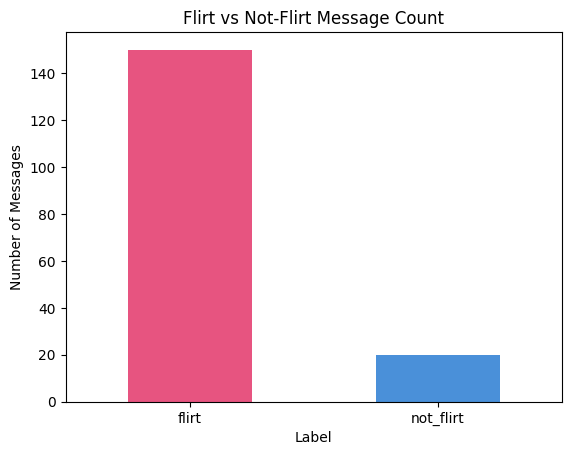

In [8]:
#7.EDA – CLASS DISTRIBUTION

# EDA → Exploratory Data Analysis
# EDA is the process of exploring, understanding,
# and visualizing the dataset before building a model.

df['label'].value_counts().plot(kind='bar', color=['#e75480', '#4a90d9'])
# df → DataFrame containing the dataset
# ['label'] → Selects the label column
# value_counts() → Counts the number of messages in each class
# plot() → Creates the visualization
# kind='bar' → Creates a bar chart
# color → Assigns different colors to the bars

plt.title('Flirt vs Not-Flirt Message Count')
# plt → Matplotlib plotting module
# title() → Adds a title to the chart
# 'Flirt vs Not-Flirt Message Count' → Title of the chart

plt.xlabel('Label')
# xlabel() → Adds a label to the X-axis
# 'Label' → Represents the message classes

plt.ylabel('Number of Messages')
# ylabel() → Adds a label to the Y-axis
# 'Number of Messages' → Represents the number of messages

plt.xticks(rotation=0)
# xticks() → Controls the X-axis tick labels
# rotation=0 → Keeps the labels horizontal

plt.show()
# show() → Displays the completed chart

# EDA EXPLANATION:
# This EDA step checks the distribution of the dataset classes.
# It counts Flirt and Not-Flirt messages and displays them
# in a bar chart for easy comparison.

# This helps identify whether the dataset is balanced
# or contains more messages in one class.

In [9]:
#8.EDA – MOST COMMON WORDS IN EACH CLASS

from collections import Counter
# from → Python keyword used to import a specific part of a module
# collections → Python module containing useful data structures
# import → Imports the specified function or class
# Counter → Counts the frequency of items

def top_words(label, n=10):
    words = ' '.join(df[df['label'] == label]['clean_text']).split()
    return Counter(words).most_common(n)

# def → Defines a function
# top_words → Name of the function
# label → Specifies the message class
# n=10 → Sets the number of top words to 10
# df → DataFrame containing the dataset
# ['label'] == label → Selects messages matching the given label
# ['clean_text'] → Selects the cleaned text column
# join() → Combines the text messages into one string
# split() → Splits the text into individual words
# Counter(words) → Counts each word
# most_common(n) → Returns the n most frequent words

print('Top FLIRT words:', top_words('flirt'))
# print() → Displays the result
# 'Top FLIRT words:' → Label for the Flirt word list
# top_words('flirt') → Finds the 10 most common Flirt words

print('Top NOT_FLIRT words:', top_words('not_flirt'))
# print() → Displays the result
# 'Top NOT_FLIRT words:' → Label for the Not-Flirt word list
# top_words('not_flirt') → Finds the 10 most common Not-Flirt words

# This cell identifies the most common words in
# the FLIRT and NOT_FLIRT message classes.

Top FLIRT words: [('you', 91), ('i', 86), ('to', 53), ('a', 43), ('my', 35), ('think', 33), ('me', 25), ('have', 25), ('youre', 25), ('make', 24)]
Top NOT_FLIRT words: [('the', 17), ('i', 6), ('you', 4), ('to', 4), ('is', 4), ('for', 4), ('assignment', 3), ('please', 3), ('at', 3), ('have', 3)]


In [10]:
#9.TRAIN-TEST SPLIT

# TRAIN-TEST SPLIT → Divides the dataset into training and testing sets.
# Training data → Used to train the machine learning model.
# Testing data → Used to evaluate the model's performance.

X = df['clean_text']
# X → Input features
# df → DataFrame containing the dataset
# ['clean_text'] → Selects the cleaned text column

y = df['label']
# y → Target variable
# ['label'] → Selects the class labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# train_test_split() → Splits data into training and testing sets
# X → Input text data
# y → Target labels
# test_size=0.2 → Uses 20% of the data for testing
# random_state=42 → Keeps the split consistent each time
# stratify=y → Maintains the same class proportion in both sets
# X_train → Training input data
# X_test → Testing input data
# y_train → Training labels
# y_test → Testing labels

print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])
# print() → Displays the results
# X_train.shape[0] → Number of training samples
# X_test.shape[0] → Number of testing samples

# EDA / DATA PREPARATION EXPLANATION:
# This step divides the cleaned text data into training and testing sets.
# 80% of the data is used for training and 20% for testing.
# Stratification keeps the Flirt and Not-Flirt class distribution balanced.

# This prepares the dataset for machine learning model training
# and performance evaluation.

Train size: 136 | Test size: 34


In [11]:
#10.RESEARCH METHODOLOGY – COUNTVECTORIZER + TF-IDF WITH CLASSIFICATION ALGORITHMS

vectorizers = {
    'CountVectorizer': CountVectorizer(),
    'TFIDF': TfidfVectorizer()
}
# vectorizers → Stores different text vectorization methods
# CountVectorizer → Converts text into word-count features
# TfidfVectorizer → Converts text into TF-IDF numerical features
# TF-IDF → Gives importance to words based on their frequency

classifiers = {
    'NaiveBayes': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'LinearSVC': LinearSVC()
}
# classifiers → Stores different classification algorithms
# NaiveBayes → Probabilistic classification algorithm
# LogisticRegression → Classification algorithm for predicting classes
# max_iter=1000 → Sets the maximum number of training iterations
# LinearSVC → Linear Support Vector Classification algorithm

results = []
# results → Creates an empty list to store model results

for vec_name, vectorizer in vectorizers.items():
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

# for → Loops through each vectorizer
# vec_name → Stores the vectorizer name
# vectorizer → Stores the vectorizer object
# items() → Returns each dictionary key and value
# fit_transform() → Learns the vocabulary and transforms training text
# transform() → Converts testing text using the learned vocabulary

    for clf_name, clf in classifiers.items():
        clf.fit(X_train_vec, y_train)
        preds = clf.predict(X_test_vec)
        acc = accuracy_score(y_test, preds)
        results.append({'Vectorizer': vec_name, 'Classifier': clf_name, 'Accuracy': round(acc, 4)})

# clf_name → Stores the classifier name
# clf → Stores the classifier object
# fit() → Trains the classifier using training data
# predict() → Predicts labels for the test data
# accuracy_score() → Calculates prediction accuracy
# preds → Stores predicted labels
# append() → Adds the model results to the list
# round(acc, 4) → Rounds accuracy to 4 decimal places

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
# pd.DataFrame() → Converts results into a DataFrame
# sort_values() → Sorts the results by accuracy
# 'Accuracy' → Column used for sorting
# ascending=False → Places highest accuracy first
# reset_index() → Resets the DataFrame index
# drop=True → Removes the old index

results_df
# Displays the final comparison of vectorizers and classifiers

# RESEARCH METHODOLOGY EXPLANATION:
# This step compares different text vectorization techniques
# with different machine learning classification algorithms.
# CountVectorizer and TF-IDF convert text into numerical features.
# Naive Bayes, Logistic Regression, and Linear SVC classify the messages.
# Accuracy is calculated to compare the performance of each combination.

# This methodology helps identify how different
# vectorizers and classifiers perform on the dataset.

,Vectorizer,Classifier,Accuracy
0,CountVectorizer,NaiveBayes,0.9706
1,CountVectorizer,LinearSVC,0.9412
2,TFIDF,LinearSVC,0.9118
3,CountVectorizer,LogisticRegression,0.8824
4,TFIDF,NaiveBayes,0.8824
5,TFIDF,LogisticRegression,0.8824


In [12]:
#11.FINAL MODEL – SELECT AND TRAIN THE BEST COMBINATION

best_row = results_df.iloc[0]
# best_row → Variable used to store the best model result
# = → Assignment operator; assigns the value on the right to the variable on the left
# results_df → DataFrame containing vectorizer, classifier, and accuracy results
# . → Accesses an attribute or method of an object
# iloc → Integer-location based indexing method in pandas
# [0] → Selects the first row
# Overall → Selects the first/highest-accuracy model combination

print('Best combination:', best_row['Vectorizer'], '+', best_row['Classifier'], '| Accuracy:', best_row['Accuracy'])
# print → Displays information on the screen
# 'Best combination:' → Text displayed before the model combination
# best_row → Selected best model row
# ['Vectorizer'] → Selects the Vectorizer column value
# 'Vectorizer' → Name of the text vectorization method
# '+' → Displays a plus symbol between vectorizer and classifier
# ['Classifier'] → Selects the Classifier column value
# 'Classifier' → Name of the machine learning algorithm
# '|' → Separates the model information from accuracy
# 'Accuracy:' → Text identifying the accuracy value
# ['Accuracy'] → Selects the accuracy value
# Overall → Prints the best vectorizer, classifier, and accuracy

final_vectorizer = TfidfVectorizer() if best_row['Vectorizer'] == 'TFIDF' else CountVectorizer()
# final_vectorizer → Variable storing the final selected vectorizer
# = → Assignment operator
# TfidfVectorizer() → Creates a TF-IDF vectorizer
# if → Checks a condition
# best_row → Contains the best model information
# ['Vectorizer'] → Gets the selected vectorizer name
# == → Comparison operator used to check equality
# 'TFIDF' → Name of the TF-IDF vectorizer
# else → Executes when the condition is false
# CountVectorizer() → Creates a CountVectorizer
# Overall → Selects the vectorizer used by the best model

final_classifier_map = {
    'NaiveBayes': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'LinearSVC': LinearSVC()
}
# final_classifier_map → Dictionary containing available classifiers
# = → Assignment operator
# { } → Creates a dictionary
# 'NaiveBayes' → Name assigned to the Naive Bayes classifier
# : → Separates a dictionary key from its value
# MultinomialNB() → Creates a Multinomial Naive Bayes classifier
# 'LogisticRegression' → Name assigned to Logistic Regression
# LogisticRegression() → Creates a Logistic Regression classifier
# max_iter → Maximum number of training iterations
# 1000 → Maximum iteration value
# 'LinearSVC' → Name assigned to Linear Support Vector Classifier
# LinearSVC() → Creates a Linear SVC classifier

final_classifier = final_classifier_map[best_row['Classifier']]
# final_classifier → Variable storing the selected final classifier
# = → Assignment operator
# final_classifier_map → Dictionary containing classifiers
# [ ] → Accesses a dictionary value using a key
# best_row → Contains the best model result
# ['Classifier'] → Gets the name of the best classifier
# Overall → Selects the classifier used by the best model

X_train_final = final_vectorizer.fit_transform(X_train)
# X_train_final → Final numerical training features
# = → Assignment operator
# final_vectorizer → Selected vectorizer
# fit_transform → Learns vocabulary and converts text into numerical features
# X_train → Training text data
# Overall → Converts training text into numerical data

X_test_final = final_vectorizer.transform(X_test)
# X_test_final → Final numerical testing features
# = → Assignment operator
# final_vectorizer → Selected vectorizer
# transform → Converts text using the already learned vocabulary
# X_test → Testing text data
# Overall → Converts testing text into numerical data

final_classifier.fit(X_train_final, y_train)
# final_classifier → Selected machine learning classifier
# fit → Trains the classifier
# X_train_final → Numerical training features
# y_train → Training labels
# Overall → Trains the final model using training data

final_preds = final_classifier.predict(X_test_final)
# final_preds → Variable storing final predictions
# = → Assignment operator
# final_classifier → Trained final classifier
# predict → Generates predictions
# X_test_final → Numerical testing features
# Overall → Predicts Flirt or Not-Flirt labels for test messages

print(classification_report(y_test, final_preds))
# print → Displays the result
# classification_report → Generates classification performance metrics
# y_test → Actual test labels
# final_preds → Predicted test labels
# Overall → Displays precision, recall, F1-score, and support


# FINAL MODEL EXPLANATION:
# This step selects the best-performing vectorizer and classifier.
# The selected vectorizer converts text into numerical features.
# The selected classifier is trained using the training dataset.
# The trained model predicts labels for the test dataset.
# The classification report evaluates the final model performance.

# This cell creates, trains, and evaluates the final NLP model.

Best combination: CountVectorizer + NaiveBayes | Accuracy: 0.9706
              precision    recall  f1-score   support

       flirt       0.97      1.00      0.98        30
   not_flirt       1.00      0.75      0.86         4

    accuracy                           0.97        34
   macro avg       0.98      0.88      0.92        34
weighted avg       0.97      0.97      0.97        34



In [13]:
#12.RETRAIN FINAL MODEL ON FULL DATASET & SAVE IT

final_vectorizer_full = TfidfVectorizer() if best_row['Vectorizer'] == 'TFIDF' else CountVectorizer()
# final_vectorizer_full → Stores the vectorizer for the full dataset
# = → Assignment operator
# TfidfVectorizer() → Creates a TF-IDF vectorizer
# if → Checks a condition
# best_row → Contains the best model result
# ['Vectorizer'] → Selects the Vectorizer value
# == → Checks whether two values are equal
# 'TFIDF' → Name of the TF-IDF vectorizer
# else → Executes when the condition is false
# CountVectorizer() → Creates a CountVectorizer
# Overall → Selects the best-performing vectorizer

final_classifier_full = final_classifier_map[best_row['Classifier']]
# final_classifier_full → Stores the final classifier
# = → Assignment operator
# final_classifier_map → Dictionary containing classifiers
# [ ] → Accesses a dictionary value
# best_row → Contains the best model result
# ['Classifier'] → Selects the best classifier name
# Overall → Selects the classifier used for the final model

X_full_vec = final_vectorizer_full.fit_transform(X)
# X_full_vec → Stores the numerical representation of the full dataset
# = → Assignment operator
# final_vectorizer_full → Selected vectorizer
# fit_transform → Learns vocabulary and converts text into numerical features
# X → Complete text dataset
# Overall → Converts the entire dataset into numerical features

final_classifier_full.fit(X_full_vec, y)
# final_classifier_full → Final selected classifier
# fit → Trains the classifier
# X_full_vec → Numerical features from the full dataset
# y → Complete target labels
# Overall → Trains the final model using the full dataset

with open('flirt_vectorizer.pkl', 'wb') as f:
    pickle.dump(final_vectorizer_full, f)
# with → Creates a controlled block for working with a file
# open → Opens or creates a file
# 'flirt_vectorizer.pkl' → File name for saving the vectorizer
# 'wb' → Opens the file in write-binary mode
# as → Assigns the opened file to a variable
# f → Variable representing the opened file
# pickle → Python module used to save Python objects
# dump → Saves an object into a file
# final_vectorizer_full → Vectorizer being saved
# Overall → Saves the trained vectorizer to disk

with open('flirt_model.pkl', 'wb') as f:
    pickle.dump(final_classifier_full, f)
# with → Creates a controlled file-handling block
# open → Opens or creates a file
# 'flirt_model.pkl' → File name for saving the model
# 'wb' → Opens the file in write-binary mode
# as → Assigns the opened file to a variable
# f → Variable representing the opened file
# pickle → Python object serialization module
# dump → Saves the object into the file
# final_classifier_full → Trained classifier being saved
# Overall → Saves the trained model to disk

print('Model and vectorizer saved to disk.')
# print → Displays text on the screen
# 'Model and vectorizer saved to disk.' → Confirmation message
# Overall → Confirms that both files were successfully saved


# RESEARCH METHODOLOGY EXPLANATION:
# This step retrains the selected final model using the full dataset.
# The complete dataset is used so that the final model can learn
# from all available messages before deployment.
# The vectorizer and trained classifier are saved as .pkl files.
# These saved files can later be loaded and used for prediction.

# This cell trains the final NLP model on the full dataset
# and saves both the vectorizer and classifier to disk.

Model and vectorizer saved to disk.


In [14]:
#13.PARSE THE WHATSAPP CHAT FILE

chat_pattern = re.compile(
    r'^\[(\d{1,2}/\d{1,2}/\d{2,4}),\s*(\d{1,2}:\d{2}(?::\d{2})?\s?[APap][Mm])\]\s*([^:]+):\s*(.*)$'
)

# chat_pattern → Variable that stores the regular expression pattern
# = → Assignment operator; assigns a value to a variable
# re → Python regular expression module
# . → Accesses a function or method from a module/object
# compile → Creates a regular expression pattern
# ( ) → Groups the regular expression
# r → Raw string; treats backslashes as literal characters
# ^ → Matches the beginning of the line
# \[ → Matches the opening [ character
# \d → Matches any digit from 0 to 9
# {1,2} → Matches 1 or 2 digits
# / → Matches the / character
# , → Matches the comma character
# \s → Matches whitespace
# * → Matches zero or more occurrences
# \d{2,4} → Matches 2 to 4 digits
# : → Matches the colon character
# ? → Makes the previous pattern optional
# [APap] → Matches A, P, a, or p
# [Mm] → Matches M or m
# \] → Matches the closing ] character
# [^:] → Matches any character except :
# + → Matches one or more occurrences
# .* → Matches any characters
# $ → Matches the end of the line


records = []
# records → Variable used to store parsed messages
# = → Assignment operator
# [] → Creates an empty list


current = None
# current → Variable used to store the current message
# = → Assignment operator
# None → Represents no value


with open('chat.txt', encoding='utf-8') as f:
# with → Creates a controlled block for file handling
# open → Opens a file
# 'chat.txt' → Name of the WhatsApp chat file
# encoding → Specifies the character encoding
# 'utf-8' → Unicode encoding used to read the file
# as → Gives the opened file a variable name
# f → Variable representing the opened file


    for line in f:
# for → Starts a loop
# line → Variable containing one line from the file
# in → Takes each item from a collection
# f → Opened chat file
# Overall → Reads the chat file one line at a time


        line = line.rstrip('\n')
# line → Stores the current line
# = → Assignment operator
# rstrip → Removes characters from the right side
# '\n' → New-line character
# Overall → Removes the new-line character from each line


        match = chat_pattern.match(line)
# match → Variable storing the matching result
# = → Assignment operator
# chat_pattern → Regular expression pattern
# . → Accesses the method
# match → Checks the pattern from the beginning of the line
# line → Current line being checked


        if match:
# if → Checks whether a condition is true
# match → Checks whether the line matched the pattern
# : → Starts the indented code block


            if current:
                records.append(current)

# if → Checks whether a current message exists
# current → Previously stored message
# records → List containing parsed messages
# append → Adds an item to the list
# current → Adds the current message to records


            date_str, time_str, sender, message = match.groups()
# date_str → Stores the extracted date
# time_str → Stores the extracted time
# sender → Stores the extracted sender name
# message → Stores the extracted message
# = → Assignment operator
# match → Matching result
# groups → Returns all captured groups


            current = {
                'date': date_str,
                'time': time_str,
                'sender': sender.strip(),
                'message': message.strip()
            }

# current → Stores the current WhatsApp message
# {} → Creates a dictionary
# 'date' → Dictionary key for the date
# 'time' → Dictionary key for the time
# 'sender' → Dictionary key for the sender
# 'message' → Dictionary key for the message
# strip → Removes unnecessary spaces
# Overall → Creates a structured record for one WhatsApp message


        else:
# else → Runs when the line does not match a new message


            if current and line.strip():
                current['message'] += ' ' + line.strip()

# current → Checks whether a previous message exists
# and → Requires both conditions to be true
# line.strip() → Removes spaces and checks whether text remains
# current['message'] → Accesses the existing message
# += → Adds new content to the existing value
# ' ' → Adds a space between message lines
# Overall → Combines multi-line WhatsApp messages


if current:
    records.append(current)

# if → Checks whether a final message exists
# current → Final stored message
# append → Adds the final message to records


chat_df = pd.DataFrame(records)
# chat_df → Variable storing the final DataFrame
# pd → Pandas library
# . → Accesses the DataFrame function
# DataFrame → Creates a table structure
# records → Source data for the DataFrame


chat_df['datetime'] = pd.to_datetime(
    chat_df['date'] + ' ' + chat_df['time'],
    dayfirst=True,
    errors='coerce'
)

# chat_df → WhatsApp DataFrame
# ['datetime'] → Creates a new datetime column
# = → Assignment operator
# pd → Pandas library
# to_datetime → Converts text into date-time format
# chat_df['date'] → Selects the date column
# + → Combines values
# ' ' → Adds a space
# chat_df['time'] → Selects the time column
# dayfirst=True → Treats the first date value as the day
# errors='coerce' → Converts invalid dates into NaT


print(chat_df.shape)
# print → Displays output
# chat_df → WhatsApp DataFrame
# . → Accesses an attribute
# shape → Returns the number of rows and columns


chat_df.head()
# chat_df → WhatsApp DataFrame
# . → Accesses a method
# head → Returns the first rows
# () → Calls the method
# Overall → Displays the first five rows


# PARSING EXPLANATION:
# Parsing → Converting unstructured text into structured information
# WhatsApp → Source of the chat data
# Regular Expression → Pattern used to identify each message
# DataFrame → Table containing the extracted chat information
# datetime → Combined date and time information
# head() → Used to preview the parsed dataset

# This cell reads the WhatsApp chat file,
# extracts date, time, sender, and message,
# handles multi-line messages,
# and creates a structured DataFrame for NLP analysis.

(1656, 5)


C:\Users\bkann\AppData\Local\Temp\ipykernel_2148\1415789775.py:156: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chat_df['datetime'] = pd.to_datetime(


,date,time,sender,message,datetime
0,7/3/26,7:40:25 AM,Rubhini (Hope AI Mentor),"Hi K.Peratchi Kumar 👋, Just checking in regarding your mentorship progress I wanted to personal...",2026-03-07 07:40:25
1,7/3/26,4:24:22 PM,You,"<image omitted> Mam, Good Evening. I completed the selectk - classification and uploaded it to m...",2026-03-07 16:24:22
2,7/3/26,4:27:42 PM,Rubhini (Hope AI Mentor),Good evening! Okay sir... Let me check it,2026-03-07 16:27:42
3,7/3/26,4:29:09 PM,You,"Okay, mam 👍",2026-03-07 16:29:09
4,7/3/26,4:31:24 PM,Rubhini (Hope AI Mentor),<image omitted> Explain this in a voice note sir,2026-03-07 16:31:24


In [15]:
#14.TAG MEDIA, MISSED CALLS AND PLAIN-TEXT MESSAGES

def is_media(msg):
# def → Defines a function
# is_media → Name of the function
# (msg) → Input parameter containing one message
# : → Starts the function block

    return bool(re.search(r'<.*omitted>', msg))
# return → Sends the result back from the function
# bool → Converts the result into True or False
# re → Python regular expression module
# search → Searches for a pattern anywhere in the text
# r → Creates a raw string
# '<.*omitted>' → Pattern used to identify omitted media
# < → Matches the opening < symbol
# . → Matches any character
# * → Matches zero or more characters
# omitted → Searches for the word "omitted"
# > → Matches the closing > symbol
# msg → Message being checked
# Overall → Returns True when the message contains an omitted-media pattern


def is_missed_call(msg):
# def → Defines a function
# is_missed_call → Name of the function
# (msg) → Input parameter containing one message
# : → Starts the function block

    return bool(re.search(r'missed (voice|video) call', msg, re.I))
# return → Returns the result of the function
# bool → Converts the result into True or False
# re → Python regular expression module
# search → Searches for a pattern in the message
# r → Creates a raw string
# 'missed (voice|video) call' → Pattern for missed voice or video calls
# missed → Searches for the word "missed"
# (voice|video) → Matches either "voice" or "video"
# | → Means OR
# call → Searches for the word "call"
# msg → Message being checked
# re.I → Makes the search case-insensitive
# Overall → Returns True when the message is a missed voice or video call


chat_df['is_media'] = chat_df['message'].apply(is_media)
# chat_df → DataFrame containing the WhatsApp messages
# ['is_media'] → Creates or updates the is_media column
# = → Assignment operator
# ['message'] → Selects the message column
# apply → Applies a function to every value
# is_media → Function used to identify media messages
# Overall → Creates a True/False column for media messages


chat_df['is_missed_call'] = chat_df['message'].apply(is_missed_call)
# chat_df → WhatsApp DataFrame
# ['is_missed_call'] → Creates or updates the missed-call column
# = → Assignment operator
# ['message'] → Selects the message column
# apply → Applies a function to every message
# is_missed_call → Function used to identify missed calls
# Overall → Creates a True/False column for missed calls


chat_df['is_text'] = (~chat_df['is_media']) & (~chat_df['is_missed_call']) & (chat_df['message'].str.strip() != '')
# chat_df → WhatsApp DataFrame
# ['is_text'] → Creates or updates the plain-text column
# = → Assignment operator
# ~ → NOT operator; reverses True to False and False to True
# ['is_media'] → Selects the media indicator column
# & → AND operator; requires all conditions to be True
# ['is_missed_call'] → Selects the missed-call indicator column
# ['message'] → Selects the message column
# str → Accesses pandas string operations
# strip() → Removes spaces from the beginning and end
# != → Means "not equal to"
# '' → Empty string
# Overall → Identifies messages that are neither media nor missed calls and are not empty


print('Media messages:', chat_df['is_media'].sum())
# print → Displays the result
# 'Media messages:' → Text label
# ['is_media'] → Selects the media indicator column
# sum() → Counts True values
# Overall → Displays the total number of media messages


print('Missed calls:', chat_df['is_missed_call'].sum())
# print → Displays the result
# 'Missed calls:' → Text label
# ['is_missed_call'] → Selects the missed-call indicator column
# sum() → Counts True values
# Overall → Displays the total number of missed calls


print('Plain text messages:', chat_df['is_text'].sum())
# print → Displays the result
# 'Plain text messages:' → Text label
# ['is_text'] → Selects the plain-text indicator column
# sum() → Counts True values
# Overall → Displays the total number of plain-text messages


# EXPLANATION:
# This step identifies three types of WhatsApp chat entries:
# Media messages, missed calls, and plain-text messages.
# Regular expressions are used to detect media and missed calls.
# Boolean columns are created to classify each message.
# The sum() function counts the messages in each category.

# This cell classifies WhatsApp messages into
# media, missed calls, and plain-text messages.

Media messages: 786
Missed calls: 0
Plain text messages: 870


In [16]:
#15.APPLY THE FLIRT MODEL TO EACH CHAT ROW

text_rows = chat_df[chat_df['is_text']].copy()
# text_rows → Variable storing only plain-text chat rows
# = → Assignment operator
# chat_df → DataFrame containing the complete WhatsApp chat
# [ ] → Selects rows or columns from the DataFrame
# chat_df['is_text'] → Selects the is_text column
# → True → Selects rows where is_text is True
# copy() → Creates an independent copy of the selected rows
# Overall → Creates a separate DataFrame containing only text messages


text_rows['clean_text'] = text_rows['message'].apply(clean_text)
# text_rows → DataFrame containing text messages
# ['clean_text'] → Creates a new clean_text column
# = → Assignment operator
# ['message'] → Selects the original message column
# apply() → Applies a function to every message
# clean_text → Function used to clean the messages
# Overall → Creates cleaned text for model prediction


text_vec = final_vectorizer_full.transform(text_rows['clean_text'])
# text_vec → Variable storing numerical text features
# = → Assignment operator
# final_vectorizer_full → Final trained text vectorizer
# transform() → Converts text into numerical features
# text_rows['clean_text'] → Selects the cleaned messages
# Overall → Converts cleaned messages into the format required by the model


text_rows['flirt_prediction'] = final_classifier_full.predict(text_vec)
# text_rows → DataFrame containing text messages
# ['flirt_prediction'] → Creates a new prediction column
# = → Assignment operator
# final_classifier_full → Final trained classification model
# predict() → Predicts the class of each message
# text_vec → Numerical features given to the model
# Overall → Predicts whether each message is Flirt or Not-Flirt


chat_df = chat_df.merge(
    text_rows[['flirt_prediction']],
    left_index=True,
    right_index=True,
    how='left'
)
# chat_df → Main WhatsApp DataFrame
# = → Assignment operator
# merge() → Combines two DataFrames
# text_rows → DataFrame containing predictions
# [['flirt_prediction']] → Selects only the prediction column
# left_index=True → Uses the index of chat_df for matching
# right_index=True → Uses the index of text_rows for matching
# how='left' → Keeps all rows from the main DataFrame
# Overall → Adds the flirt predictions back to the original chat DataFrame


chat_df[['sender', 'message', 'flirt_prediction']].head(10)
# chat_df → Main WhatsApp DataFrame
# [['sender', 'message', 'flirt_prediction']] → Selects three columns
# sender → Name of the person who sent the message
# message → Original WhatsApp message
# flirt_prediction → Model's predicted class
# head() → Displays the first rows
# 10 → Displays the first 10 rows
# Overall → Shows the first 10 messages with their predictions


# EXPLANATION:
# This step applies the trained Flirt classification model
# to every plain-text message in the WhatsApp chat.
# The messages are first cleaned and converted into numerical
# features using the final vectorizer.
# The final classifier then predicts the class of each message.
# The predictions are merged back into the original chat DataFrame.

# This cell applies the trained NLP model to the WhatsApp
# chat and adds a flirt_prediction column to the dataset.

,sender,message,flirt_prediction
0,Rubhini (Hope AI Mentor),"Hi K.Peratchi Kumar 👋, Just checking in regarding your mentorship progress I wanted to personal...",flirt
1,You,"<image omitted> Mam, Good Evening. I completed the selectk - classification and uploaded it to m...",NaN
2,Rubhini (Hope AI Mentor),Good evening! Okay sir... Let me check it,flirt
3,You,"Okay, mam 👍",flirt
4,Rubhini (Hope AI Mentor),<image omitted> Explain this in a voice note sir,NaN
5,You,"Okay, mam 👍",flirt
6,You,<voice message omitted>,NaN
7,You,<voice message omitted>,NaN
8,Rubhini (Hope AI Mentor),<voice message omitted>,NaN
9,You,<image omitted> Finding out the 7 accuracy values in a single column,NaN


In [17]:
#16.FLIRT MESSAGE COUNT PER SENDER

flirt_summary = chat_df[chat_df['flirt_prediction'].notna()].groupby(['sender', 'flirt_prediction']).size().unstack(fill_value=0)
# flirt_summary → Variable that stores the flirt message summary
# = → Assignment operator
# chat_df → DataFrame containing the WhatsApp chat
# ['flirt_prediction'] → Selects the flirt prediction column
# notna() → Checks for values that are not missing
# chat_df[...] → Selects rows satisfying the condition
# groupby() → Groups the data based on selected columns
# ['sender', 'flirt_prediction'] → Groups messages by sender and prediction
# sender → Name of the person who sent the message
# flirt_prediction → Predicted Flirt or Not-Flirt class
# size() → Counts the number of rows in each group
# unstack() → Converts grouped values into separate columns
# fill_value=0 → Replaces missing combinations with zero
# Overall → Counts Flirt and Not-Flirt messages for each sender

flirt_summary
# flirt_summary → Displays the completed sender-wise summary
# Overall → Shows the number of Flirt and Not-Flirt messages sent by each person

flirt_prediction,flirt,not_flirt
sender,,
Rubhini (Hope AI Mentor),313,16
You,518,23


sender
You                         910
Rubhini (Hope AI Mentor)    746
Name: count, dtype: int64

Most Talkative: You (910 messages)
Least Talkative: Rubhini (Hope AI Mentor) (746 messages)


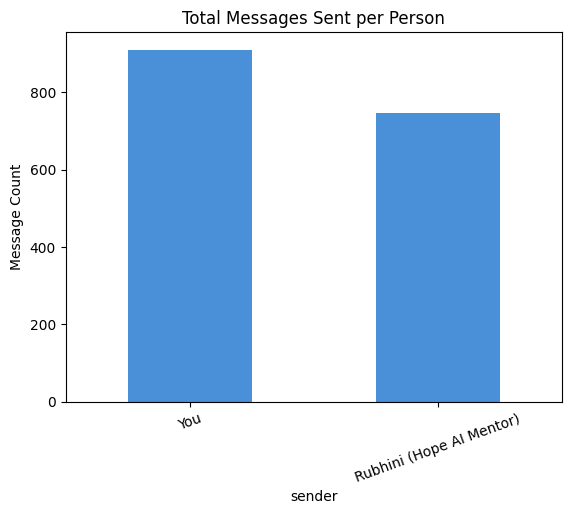

In [18]:
#17.TALKATIVE vs LESS TALKATIVE

message_counts = chat_df['sender'].value_counts()
# message_counts → Variable that stores the message count for each sender
# = → Assignment operator
# chat_df → DataFrame containing the WhatsApp chat
# ['sender'] → Selects the sender column
# value_counts() → Counts the number of messages from each sender
# Overall → Calculates how many messages each person sent

print(message_counts)
# print → Displays the result
# message_counts → Contains the message count for each sender
# Overall → Displays the total messages sent by each person


most_talkative = message_counts.idxmax()
# most_talkative → Variable storing the sender with the highest message count
# = → Assignment operator
# message_counts → Contains message counts
# idxmax() → Returns the index/name with the maximum value
# Overall → Identifies the person who sent the most messages


least_talkative = message_counts.idxmin()
# least_talkative → Variable storing the sender with the lowest message count
# = → Assignment operator
# message_counts → Contains message counts
# idxmin() → Returns the index/name with the minimum value
# Overall → Identifies the person who sent the fewest messages


print(f'\nMost Talkative: {most_talkative} ({message_counts.max()} messages)')
# print → Displays the result
# f → Creates an f-string for inserting variable values
# \n → Creates a new line
# Most Talkative → Text label
# most_talkative → Inserts the sender with the highest message count
# message_counts → Contains all sender message counts
# max() → Returns the highest message count
# messages → Text describing the count
# Overall → Displays the most talkative person and their message count


print(f'Least Talkative: {least_talkative} ({message_counts.min()} messages)')
# print → Displays the result
# f → Creates an f-string
# Least Talkative → Text label
# least_talkative → Inserts the sender with the lowest message count
# message_counts → Contains all sender message counts
# min() → Returns the lowest message count
# messages → Text describing the count
# Overall → Displays the least talkative person and their message count


message_counts.plot(kind='bar', color='#4a90d9')
# message_counts → Contains the message counts
# plot() → Creates a visualization
# kind='bar' → Creates a bar chart
# color → Specifies the bar color
# '#4a90d9' → Hexadecimal color code
# Overall → Creates a bar chart showing messages sent by each person


plt.title('Total Messages Sent per Person')
# plt → Matplotlib plotting module
# title() → Adds a title to the chart
# 'Total Messages Sent per Person' → Title of the chart


plt.ylabel('Message Count')
# plt → Matplotlib plotting module
# ylabel() → Adds a label to the Y-axis
# 'Message Count' → Name of the Y-axis


plt.xticks(rotation=20)
# plt → Matplotlib plotting module
# xticks() → Controls the X-axis tick labels
# rotation=20 → Rotates the labels by 20 degrees


plt.show()
# plt → Matplotlib plotting module
# show() → Displays the completed chart


# EXPLANATION:
# This step calculates the total number of messages
# sent by each person in the WhatsApp chat.
# idxmax() identifies the most talkative person.
# idxmin() identifies the least talkative person.
# A bar chart is created to visually compare message counts.

# This cell analyzes the conversation activity
# of each sender in the WhatsApp chat.

day_name
Monday       403
Friday       318
Thursday     317
Wednesday    276
Saturday     155
Tuesday      150
Sunday        37
Name: count, dtype: int64

Most Active Day: Monday


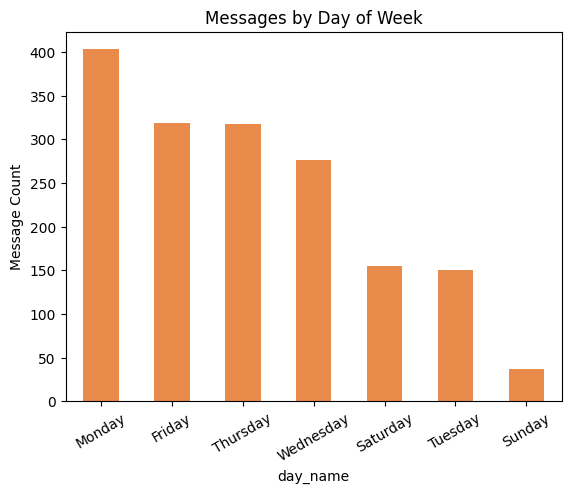

In [19]:
#18.MOST ACTIVE DAY

chat_df['day_name'] = chat_df['datetime'].dt.day_name()
# chat_df → DataFrame containing the WhatsApp chat
# ['day_name'] → Creates a new column to store the day name
# = → Assignment operator
# ['datetime'] → Selects the datetime column
# .dt → Accesses pandas datetime properties
# day_name() → Extracts the name of the day
# Overall → Creates a column containing Monday, Tuesday, Wednesday, etc.


active_day = chat_df['day_name'].value_counts()
# active_day → Variable storing the message count for each day
# = → Assignment operator
# chat_df → WhatsApp DataFrame
# ['day_name'] → Selects the day-name column
# value_counts() → Counts messages for each day
# Overall → Calculates how many messages were sent on each day


print(active_day)
# print → Displays the result
# active_day → Contains message counts for each day
# Overall → Displays the number of messages for every day of the week


print('\nMost Active Day:', active_day.idxmax())
# print → Displays the result
# \n → Creates a new line
# 'Most Active Day:' → Text label
# active_day → Contains the daily message counts
# idxmax() → Returns the day with the highest message count
# Overall → Displays the day with the most messages


active_day.plot(kind='bar', color='#e78a4a')
# active_day → Contains the daily message counts
# plot() → Creates a visualization
# kind='bar' → Creates a bar chart
# color → Specifies the bar color
# '#e78a4a' → Hexadecimal color code
# Overall → Creates a bar chart showing messages by day


plt.title('Messages by Day of Week')
# plt → Matplotlib plotting module
# title() → Adds a title to the chart
# 'Messages by Day of Week' → Title of the chart


plt.ylabel('Message Count')
# plt → Matplotlib plotting module
# ylabel() → Adds a label to the Y-axis
# 'Message Count' → Name of the Y-axis


plt.xticks(rotation=30)
# plt → Matplotlib plotting module
# xticks() → Controls the X-axis tick labels
# rotation=30 → Rotates the labels by 30 degrees


plt.show()
# plt → Matplotlib plotting module
# show() → Displays the completed chart


# EXPLANATION:
# This step identifies the most active day of the week
# based on the number of WhatsApp messages.
# The datetime column is used to extract the day name.
# value_counts() counts messages for each day.
# idxmax() identifies the day with the highest message count.
# A bar chart visually compares the message count for each day.

# This cell identifies and visualizes the most active
# day of the week in the WhatsApp conversation.

hour
5       3
6       1
7      17
8       9
9      29
10     45
11     57
12     76
13     74
14    201
15    290
16    256
17    174
18    247
19    102
20     34
21     15
22     26
Name: count, dtype: int64

Most Active Hour: 15 :00


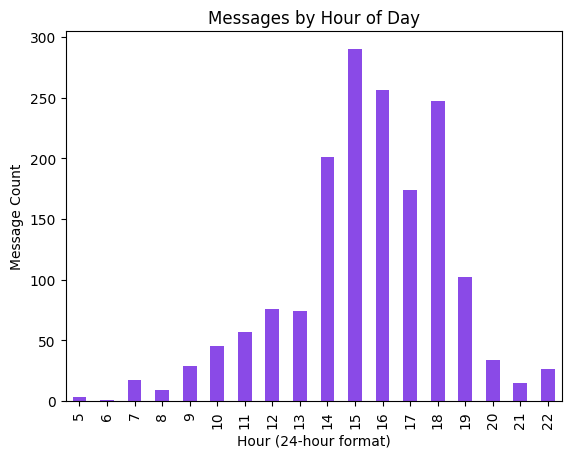

In [20]:
#19.MOST ACTIVE TIME (HOUR OF DAY)

chat_df['hour'] = chat_df['datetime'].dt.hour
# chat_df → DataFrame containing the WhatsApp chat
# ['hour'] → Creates a new column named hour
# = → Assignment operator
# ['datetime'] → Selects the datetime column
# .dt → Accesses pandas datetime properties
# hour → Extracts the hour from the datetime value
# Overall → Stores the hour of each message in a new column


active_hour = chat_df['hour'].value_counts().sort_index()
# active_hour → Variable storing the message count for each hour
# = → Assignment operator
# chat_df → WhatsApp DataFrame
# ['hour'] → Selects the hour column
# value_counts() → Counts messages for each hour
# sort_index() → Sorts the results by hour
# Overall → Creates an ordered message count for each hour of the day


print(active_hour)
# print → Displays the result
# active_hour → Contains the message count for each hour
# Overall → Displays the number of messages sent during each hour


print('\nMost Active Hour:', active_hour.idxmax(), ':00')
# print → Displays the result
# \n → Creates a new line
# 'Most Active Hour:' → Text label
# active_hour → Contains the hourly message counts
# idxmax() → Returns the hour with the highest message count
# ':00' → Adds minutes as 00
# Overall → Displays the hour with the highest number of messages


active_hour.plot(kind='bar', color='#8a4ae7')
# active_hour → Contains the hourly message counts
# plot() → Creates a visualization
# kind='bar' → Creates a bar chart
# color → Specifies the bar color
# '#8a4ae7' → Hexadecimal color code
# Overall → Creates a bar chart showing messages by hour


plt.title('Messages by Hour of Day')
# plt → Matplotlib plotting module
# title() → Adds a title to the chart
# 'Messages by Hour of Day' → Title of the chart


plt.xlabel('Hour (24-hour format)')
# plt → Matplotlib plotting module
# xlabel() → Adds a label to the X-axis
# 'Hour (24-hour format)' → Name of the X-axis
# 24-hour format → Represents time from 00 to 23


plt.ylabel('Message Count')
# plt → Matplotlib plotting module
# ylabel() → Adds a label to the Y-axis
# 'Message Count' → Name of the Y-axis


plt.show()
# plt → Matplotlib plotting module
# show() → Displays the completed chart


# EXPLANATION:
# This step identifies the most active hour of the day
# based on the number of WhatsApp messages.
# The datetime column is used to extract the hour.
# value_counts() counts messages for each hour.
# sort_index() arranges the hours in chronological order.
# idxmax() identifies the hour with the highest message count.
# A bar chart visually shows message activity throughout the day.

# This cell identifies and visualizes the most active
# hour of the day in the WhatsApp conversation.

In [21]:
#20.MEDIA COUNT SENT BY EACH PERSON

def media_type(msg):
# def → Defines a function
# media_type → Name of the function
# msg → Input parameter containing one message
# : → Starts the function block

    m = re.search(r'<(.*?) omitted>', msg)
# m → Variable storing the search result
# = → Assignment operator
# re → Python regular expression module
# . → Accesses a method
# search → Searches for a pattern inside the message
# r → Creates a raw string
# < → Matches the opening < symbol
# (.*?) → Captures the media type
# . → Matches any character
# *? → Matches characters using a non-greedy approach
# omitted → Searches for the word "omitted"
# > → Matches the closing > symbol
# msg → Message being searched

    return m.group(1) if m else None
# return → Sends a result back from the function
# m.group(1) → Returns the first captured group
# if → Checks a condition
# m → Checks whether a match was found
# else → Provides an alternative result
# None → Represents no value
# Overall → Returns the media type when found; otherwise returns None


media_df = chat_df[chat_df['is_media']].copy()
# media_df → DataFrame containing media messages
# = → Assignment operator
# chat_df → Complete WhatsApp DataFrame
# ['is_media'] → Selects the media indicator column
# copy() → Creates an independent copy
# Overall → Creates a separate DataFrame containing only media messages


media_df['media_type'] = media_df['message'].apply(media_type)
# media_df → DataFrame containing media messages
# ['media_type'] → Creates a new media_type column
# = → Assignment operator
# ['message'] → Selects the message column
# apply() → Applies a function to every message
# media_type → Function used to identify the type of media
# Overall → Identifies the media type for each media message


media_summary = media_df.groupby(['sender', 'media_type']).size().unstack(fill_value=0)
# media_summary → Variable storing the media count summary
# = → Assignment operator
# media_df → DataFrame containing media messages
# groupby() → Groups the data
# ['sender', 'media_type'] → Groups by sender and media type
# sender → Person who sent the media
# media_type → Type of media sent
# size() → Counts the number of records in each group
# unstack() → Converts grouped values into separate columns
# fill_value=0 → Replaces missing values with zero
# Overall → Counts each media type sent by each person


media_summary['Total'] = media_summary.sum(axis=1)
# media_summary → Media summary DataFrame
# ['Total'] → Creates a Total column
# = → Assignment operator
# sum() → Adds the values together
# axis=1 → Calculates the sum across each row
# Overall → Calculates the total media sent by each person


media_summary
# media_summary → Displays the completed media summary
# Overall → Shows media counts and total media sent by each person


# EXPLANATION:
# This step analyzes the media messages sent by each person.
# The media_type() function identifies the type of omitted media.
# The messages are grouped by sender and media type.
# The Total column calculates the total media sent by each person.

# This cell shows the media type and total media count
# for each person in the WhatsApp conversation.

media_type,document,image,video,voice message,Total
sender,,,,,
Rubhini (Hope AI Mentor),2,68,0,347,417
You,17,310,4,38,369


In [22]:
#21.MISSED CALL COUNT – ALL

missed_calls_df = chat_df[chat_df['is_missed_call']]
# missed_calls_df → DataFrame containing all missed-call messages
# = → Assignment operator
# chat_df → DataFrame containing the WhatsApp chat
# ['is_missed_call'] → Selects the missed-call column
# chat_df[...] → Selects rows where is_missed_call is True
# Overall → Creates a DataFrame containing only missed calls

missed_call_summary = missed_calls_df['sender'].value_counts()
# missed_call_summary → Stores the missed-call count for each sender
# = → Assignment operator
# missed_calls_df → DataFrame containing missed calls
# ['sender'] → Selects the sender column
# value_counts() → Counts the number of missed calls for each sender
# Overall → Calculates missed calls sent by each person


print('Total Missed Calls:', len(missed_calls_df))
# print → Displays the result
# 'Total Missed Calls:' → Text label
# len() → Returns the number of items/rows
# missed_calls_df → DataFrame containing all missed calls
# Overall → Displays the total number of missed calls


print(missed_call_summary if len(missed_calls_df) > 0 else 'No missed calls found in this chat export.')
# print → Displays the result
# missed_call_summary → Displays missed-call counts by sender
# if → Checks a condition
# len() → Counts the number of missed-call rows
# > → Greater-than comparison operator
# 0 → Checks whether at least one missed call exists
# else → Provides an alternative result
# 'No missed calls found in this chat export.' → Message displayed when there are no missed calls
# Overall → Displays the sender-wise missed-call count or a message saying no missed calls were found


# EXPLANATION:
# This step identifies all missed calls in the WhatsApp chat.
# The missed-call messages are filtered from the main DataFrame.
# value_counts() calculates the number of missed calls for each sender.
# len() calculates the total number of missed calls.
# The final print statement displays the results or reports that
# no missed calls were found in the chat export.

# This cell calculates the total missed calls and
# the missed-call count for each sender.

Total Missed Calls: 0
No missed calls found in this chat export.


In [23]:
#22.FINAL SUMMARY REPORT

print('===== FLIRT PREDICTION MODEL SUMMARY =====')
# print → Displays text or values on the screen
# '===== FLIRT PREDICTION MODEL SUMMARY =====' → Heading for the model summary

print('Best Vectorizer + Classifier:', best_row['Vectorizer'], '+', best_row['Classifier'])
# print → Displays the result
# 'Best Vectorizer + Classifier:' → Text label
# best_row → Stores the best-performing model result
# ['Vectorizer'] → Selects the vectorizer name
# '+' → Displays a plus sign between vectorizer and classifier
# ['Classifier'] → Selects the classifier name
# Overall → Displays the best vectorizer and classifier combination

print('Test Accuracy:', best_row['Accuracy'])
# print → Displays the result
# 'Test Accuracy:' → Text label
# best_row → Contains the best model result
# ['Accuracy'] → Selects the accuracy value
# Overall → Displays the test accuracy of the best combination

print()
# print → Displays output
# () → Empty parentheses produce a blank line
# Overall → Creates spacing between sections


print('===== TALKATIVE ANALYSIS =====')
# print → Displays text
# '===== TALKATIVE ANALYSIS =====' → Heading for talkative analysis

print('Most Talkative:', most_talkative)
# print → Displays the result
# 'Most Talkative:' → Text label
# most_talkative → Stores the sender with the highest message count
# Overall → Displays the most talkative sender

print('Least Talkative:', least_talkative)
# print → Displays the result
# 'Least Talkative:' → Text label
# least_talkative → Stores the sender with the lowest message count
# Overall → Displays the least talkative sender

print()
# print → Displays output
# () → Produces a blank line
# Overall → Separates the sections


print('===== ACTIVITY ANALYSIS =====')
# print → Displays text
# '===== ACTIVITY ANALYSIS =====' → Heading for activity analysis

print('Most Active Day:', active_day.idxmax())
# print → Displays the result
# 'Most Active Day:' → Text label
# active_day → Contains message counts for each day
# idxmax() → Returns the day with the highest message count
# Overall → Displays the most active day

print('Most Active Hour:', active_hour.idxmax(), ':00')
# print → Displays the result
# 'Most Active Hour:' → Text label
# active_hour → Contains message counts for each hour
# idxmax() → Returns the hour with the highest message count
# ':00' → Adds minutes as 00
# Overall → Displays the most active hour


print()
# print → Displays output
# () → Produces a blank line
# Overall → Separates the sections


print('===== MEDIA SUMMARY =====')
# print → Displays text
# '===== MEDIA SUMMARY =====' → Heading for media analysis

print(media_summary)
# print → Displays the media summary
# media_summary → Contains media counts grouped by sender and media type
# Overall → Displays the media analysis results


print()
# print → Displays output
# () → Produces a blank line
# Overall → Separates the sections


print('===== MISSED CALLS =====')
# print → Displays text
# '===== MISSED CALLS =====' → Heading for missed-call analysis

print('Total Missed Calls:', len(missed_calls_df))
# print → Displays the result
# 'Total Missed Calls:' → Text label
# len() → Counts the number of rows
# missed_calls_df → DataFrame containing missed-call messages
# Overall → Displays the total number of missed calls


# EXPLANATION:
# This final summary report combines the main results
# from the WhatsApp NLP analysis into one output.
# It displays the best Flirt prediction model and accuracy,
# talkative analysis, activity analysis, media summary,
# and total missed calls.

# FLIRT PREDICTION MODEL SUMMARY → Shows the selected NLP model
# TALKATIVE ANALYSIS → Shows sender message activity
# ACTIVITY ANALYSIS → Shows the most active day and hour
# MEDIA SUMMARY → Shows media activity by sender
# MISSED CALLS → Shows the total missed-call count

# This cell provides the final summary of the complete
# WhatsApp chat analysis project.

===== FLIRT PREDICTION MODEL SUMMARY =====
Best Vectorizer + Classifier: CountVectorizer + NaiveBayes
Test Accuracy: 0.9706

===== TALKATIVE ANALYSIS =====
Most Talkative: You
Least Talkative: Rubhini (Hope AI Mentor)

===== ACTIVITY ANALYSIS =====
Most Active Day: Monday
Most Active Hour: 15 :00

===== MEDIA SUMMARY =====
media_type                document  image  video  voice message  Total
sender                                                                
Rubhini (Hope AI Mentor)         2     68      0            347    417
You                             17    310      4             38    369

===== MISSED CALLS =====
Total Missed Calls: 0
